## Lionel Messi Shot Data Visualization

INFSCI 1520 Final Project -- Chase Marsalko

Lionel Messi in my opinion is the GOAT, you can argue with a wall on that one. He's provided over 1400 goal contribtuions (goals/assists) over his 971 game career so far. He has also won all of the biggest competitions around the world such as the 2022 FIFA World Cup, 2x Copa America Winner, 2008 Olympic Gold Medalist, 8-time Ballon D'or Winner, 4-time UEFA Champions League Winner, and many more that I just can't name. One thing that I have never really seen online is where all of his over 750 goals and 350 assists have come from on the field, and that is what I am doing in this notebook.

I was able to gather all the sources that I needed to complete this from the statsbomb open source data for soccer that creates coordinates on the field for where these goals and assists happened. 

In [2]:
# 1. Run once to install dependencies
!pip install statsbombpy mplsoccer wordcloud scipy reportlab matplotlib pandas seaborn

In [3]:
# 2. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud
from mplsoccer import Pitch, VerticalPitch
from scipy.ndimage import gaussian_filter
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

# ── Color palette (Argentina / Messi themed) ──────────────────────────────────
LIGHT_BLUE  = '#75AADB'   # Argentina kit blue
WHITE       = '#FFFFFF'
GOLD        = '#FFD700'   # Ballon d'Or gold
DARK_BG     = '#0D1B2A'   # dark navy background
MISS_COLOR  = '#C0392B'   # red for misses
GOAL_COLOR  = '#75AADB'   # blue for goals

plt.rcParams['figure.facecolor'] = DARK_BG
plt.rcParams['axes.facecolor']   = DARK_BG
plt.rcParams['text.color']       = WHITE
plt.rcParams['axes.labelcolor']  = WHITE
plt.rcParams['xtick.color']      = WHITE
plt.rcParams['ytick.color']      = WHITE
plt.rcParams['axes.edgecolor']   = WHITE

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [7]:
# 3. Load Messi's shot data from StatsBomb
# ── Auto-discover Messi-relevant competitions, filtered to his actual career years ──
available = sb.competitions()

# Competition IDs relevant to Messi + lambdas to filter by season name
MESSI_COMPS = {
    11:  ('Barcelona',   lambda s: any(str(y) in s for y in    # La Liga – Messi debut Oct 2004
                         range(2004, 2022))),
    16:  ('Barcelona',   lambda s: any(str(y) in s for y in    # UCL – first app was 2004/05
                         range(2005, 2020))),
    57:  ('Barcelona',   lambda s: any(str(y) in s for y in    # Copa del Rey – 2004–2021
                         range(2004, 2022))),
    7:   ('PSG',         lambda s: any(x in s for x in         # Ligue 1 – his two seasons only
                         ['2021/2022', '2022/2023'])),
    253: ('Inter Miami', lambda s: '2023' in s),                # MLS – 2023 only
    43:  ('Argentina',   lambda s: '2022' in s),                # World Cup – 2022 only
    223: ('Argentina',   lambda s: '2024' in s),                # Copa América – 2024 only
}

valid_comps = []
for _, row in available.iterrows():
    cid = row['competition_id']
    if cid in MESSI_COMPS:
        era, season_filter = MESSI_COMPS[cid]
        if season_filter(row['season_name']):
            label = f"{row['competition_name']} {row['season_name']}"
            valid_comps.append((cid, row['season_id'], label, era))

print(f'Found {len(valid_comps)} Messi-relevant competitions:\n')
for cid, sid, lbl, era in valid_comps:
    print(f'  [{era:12s}]  comp={cid}  season={sid}  →  {lbl}')

Found 34 Messi-relevant competitions:

  [Barcelona   ]  comp=16  season=4  →  Champions League 2018/2019
  [Barcelona   ]  comp=16  season=1  →  Champions League 2017/2018
  [Barcelona   ]  comp=16  season=2  →  Champions League 2016/2017
  [Barcelona   ]  comp=16  season=27  →  Champions League 2015/2016
  [Barcelona   ]  comp=16  season=26  →  Champions League 2014/2015
  [Barcelona   ]  comp=16  season=25  →  Champions League 2013/2014
  [Barcelona   ]  comp=16  season=24  →  Champions League 2012/2013
  [Barcelona   ]  comp=16  season=23  →  Champions League 2011/2012
  [Barcelona   ]  comp=16  season=22  →  Champions League 2010/2011
  [Barcelona   ]  comp=16  season=21  →  Champions League 2009/2010
  [Barcelona   ]  comp=16  season=41  →  Champions League 2008/2009
  [Barcelona   ]  comp=16  season=39  →  Champions League 2006/2007
  [Barcelona   ]  comp=16  season=37  →  Champions League 2004/2005
  [Argentina   ]  comp=223  season=282  →  Copa America 2024
  [Argentina   ]  c

In [9]:
# 4. Pull all Messi shots across every valid competition
all_shots = []

for comp_id, season_id, label, era in valid_comps:  
    print(f'Loading: {label}...', end=' ')
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        for match_id in matches['match_id']:
            events = sb.events(match_id=match_id)
            shots = events[
                (events['type'] == 'Shot') &
                (events['player'].str.contains('Messi', na=False))
            ].copy()
            if not shots.empty:
                shots['competition'] = label
                shots['era'] = era   
                all_shots.append(shots)
        print('done')
    except Exception as e:
        print(f'SKIPPED ({e})')

df = pd.concat(all_shots, ignore_index=True)
print(f'\n✅ Total Messi shots loaded: {len(df):,}')

Loading: Champions League 2018/2019... done
Loading: Champions League 2017/2018... done
Loading: Champions League 2016/2017... done
Loading: Champions League 2015/2016... done
Loading: Champions League 2014/2015... done
Loading: Champions League 2013/2014... done
Loading: Champions League 2012/2013... done
Loading: Champions League 2011/2012... done
Loading: Champions League 2010/2011... done
Loading: Champions League 2009/2010... done
Loading: Champions League 2008/2009... done
Loading: Champions League 2006/2007... done
Loading: Champions League 2004/2005... done
Loading: Copa America 2024... done
Loading: FIFA World Cup 2022... done
Loading: La Liga 2020/2021... done
Loading: La Liga 2019/2020... done
Loading: La Liga 2018/2019... done
Loading: La Liga 2017/2018... done
Loading: La Liga 2016/2017... done
Loading: La Liga 2015/2016... done
Loading: La Liga 2014/2015... done
Loading: La Liga 2013/2014... done
Loading: La Liga 2012/2013... done
Loading: La Liga 2011/2012... done
Loadin

In [11]:
# 5. Parse coordinates and key columns
print(df['player'].value_counts())
df['x'] = df['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
df['y'] = df['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
df['is_goal']   = df['shot_outcome'].apply(lambda o: 1 if o == 'Goal' else 0)
df['technique'] = df['shot_technique'].fillna('Unknown')
df['body_part'] = df['shot_body_part'].fillna('Unknown')
df['shot_type'] = df['shot_type'].fillna('Open Play')
df['xg']        = pd.to_numeric(df['shot_statsbomb_xg'], errors='coerce').fillna(0)

df.dropna(subset=['x', 'y'], inplace=True)

goals  = df[df['is_goal'] == 1]
misses = df[df['is_goal'] == 0]

df.to_csv('data.csv', index=False)

print(f'Total shots:  {len(df):,}')
print(f'Goals:        {len(goals):,}')
print(f'Misses:       {len(misses):,}')
print(f'Goal rate:    {len(goals)/len(df)*100:.1f}%')
print(f'Total xG:     {df["xg"].sum():.1f}')
print('\ndata.csv saved ✅')

player
Lionel Andrés Messi Cuccittini    2632
Name: count, dtype: int64
Total shots:  2,632
Goals:        508
Misses:       2,124
Goal rate:    19.3%
Total xG:     359.0

data.csv saved ✅


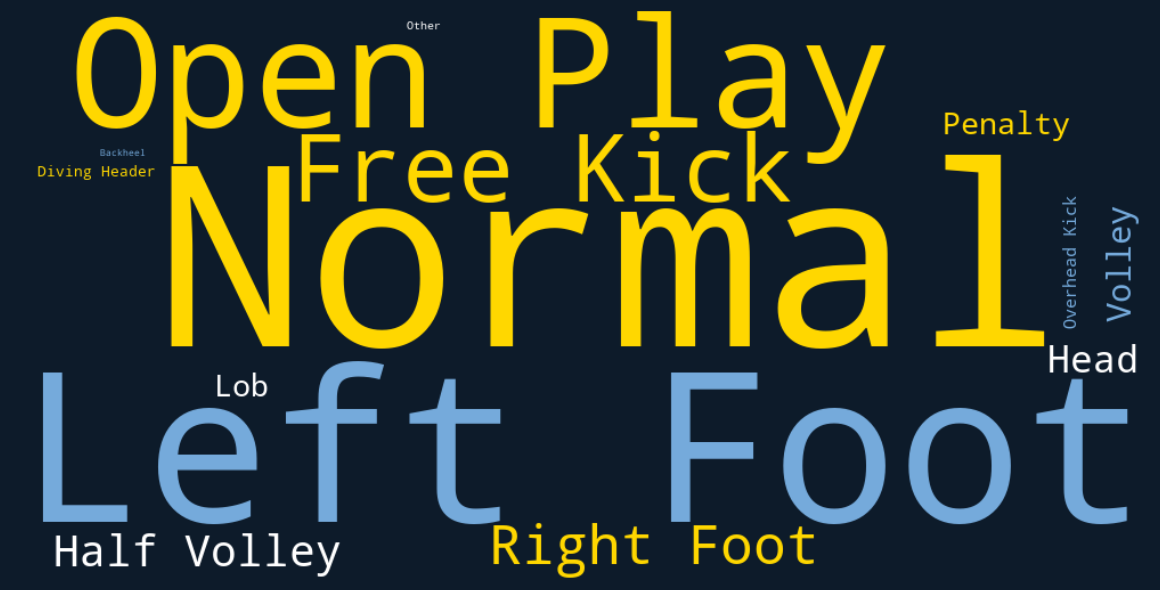

Saved fig1_wordcloud.png


In [13]:
# Figure 1 — Word Cloud
from wordcloud import WordCloud

word_tokens = (
    df['technique'].tolist() +
    df['body_part'].tolist() +
    df['shot_type'].tolist()
)
word_freq = pd.Series(word_tokens).value_counts().to_dict()

wc = WordCloud(
    width=1000, height=500,
    background_color='#0D1B2A',
    color_func=lambda *args, **kwargs: np.random.choice([LIGHT_BLUE, WHITE, GOLD]),
    max_words=80,
    prefer_horizontal=0.7
).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=DARK_BG)
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig1_wordcloud.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig1_wordcloud.png')

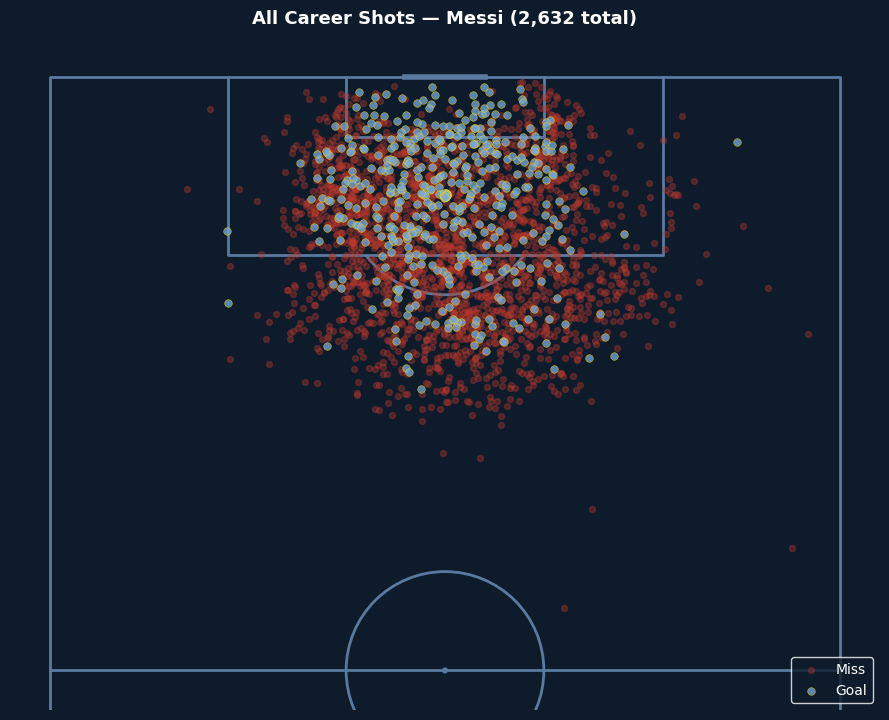

Saved fig2_all_shots.png


In [16]:
# Figure 2 — All Career Shots on Pitch
from mplsoccer import VerticalPitch

pitch = VerticalPitch(
    pitch_type='statsbomb',
    pitch_color=DARK_BG, line_color='#5A7A9F',
    half=True
)
fig, ax = pitch.draw(figsize=(9, 10))
fig.set_facecolor(DARK_BG)  

pitch.scatter(misses['x'], misses['y'], ax=ax,
              s=18, color=MISS_COLOR, alpha=0.35, label='Miss', zorder=3)
pitch.scatter(goals['x'], goals['y'], ax=ax,
              s=30, color=GOAL_COLOR, alpha=0.75, label='Goal',
              edgecolors=GOLD, linewidths=0.4, zorder=4)

ax.set_title(f"All Career Shots — Messi ({len(df):,} total)",
             fontsize=13, color=WHITE, pad=10, fontweight='bold')
ax.legend(loc='lower right', fontsize=10,
          facecolor=DARK_BG, edgecolor=WHITE, labelcolor=WHITE)
plt.tight_layout()
plt.savefig('fig2_all_shots.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig2_all_shots.png')

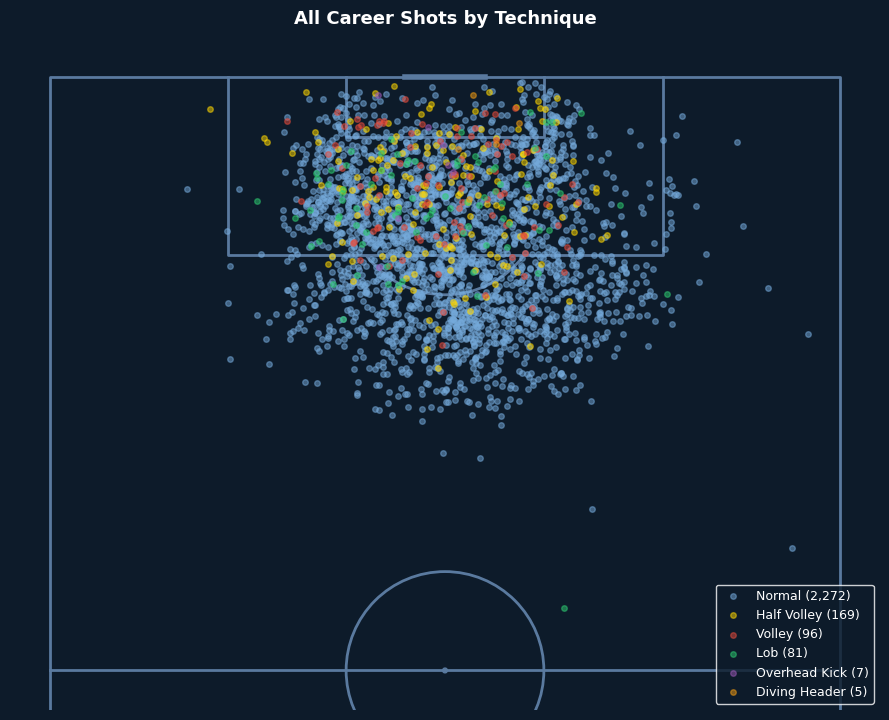

Saved fig3_shots_by_technique.png


In [18]:
# Figure 3 — All Career Shots by Technique
top_techniques = df['technique'].value_counts().nlargest(6).index.tolist()
df_tech = df[df['technique'].isin(top_techniques)].copy()

tech_palette = ['#75AADB', '#FFD700', '#E74C3C', '#2ECC71', '#9B59B6', '#F39C12']
tech_color_map = {t: tech_palette[i] for i, t in enumerate(top_techniques)}

pitch = VerticalPitch(
    pitch_type='statsbomb',
    pitch_color=DARK_BG, line_color='#5A7A9F',
    half=True
)
fig, ax = pitch.draw(figsize=(9, 10))
fig.set_facecolor(DARK_BG)

for tech in top_techniques:
    subset = df_tech[df_tech['technique'] == tech]
    pitch.scatter(subset['x'], subset['y'], ax=ax,
                  s=16, color=tech_color_map[tech], alpha=0.5,
                  label=f'{tech} ({len(subset):,})', zorder=3)

ax.set_title("All Career Shots by Technique",
             fontsize=13, color=WHITE, pad=10, fontweight='bold')
ax.legend(loc='lower right', fontsize=9,
          facecolor=DARK_BG, edgecolor=WHITE, labelcolor=WHITE)
plt.tight_layout()
plt.savefig('fig3_shots_by_technique.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig3_shots_by_technique.png')

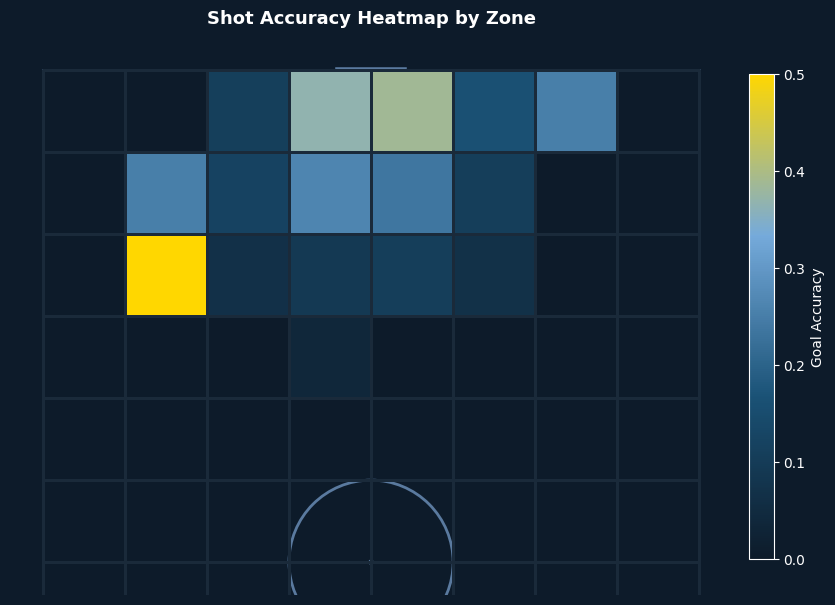

Saved fig4_accuracy_heatmap.png


In [20]:
# Figure 4 — Shot Accuracy Heatmap by Zone
from matplotlib.colors import LinearSegmentedColormap

pitch = VerticalPitch(
    pitch_type='statsbomb',
    pitch_color=DARK_BG, line_color='#5A7A9F',
    half=True
)
fig, ax = pitch.draw(figsize=(9, 10))
fig.set_facecolor(DARK_BG)

bin_stats = pitch.bin_statistic(
    df['x'], df['y'],
    values=df['is_goal'],
    statistic='mean',
    bins=(12, 8)
)

cmap = LinearSegmentedColormap.from_list(
    'messi_accuracy',
    ['#0D1B2A', '#1a5276', LIGHT_BLUE, GOLD]
)

pcm = pitch.heatmap(bin_stats, ax=ax, cmap=cmap, edgecolors='#1a2a3a')
cbar = fig.colorbar(pcm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Goal Accuracy', color=WHITE, fontsize=10)
cbar.ax.yaxis.set_tick_params(color=WHITE)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=WHITE)

ax.set_title("Shot Accuracy Heatmap by Zone",
             fontsize=13, color=WHITE, pad=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_accuracy_heatmap.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig4_accuracy_heatmap.png')

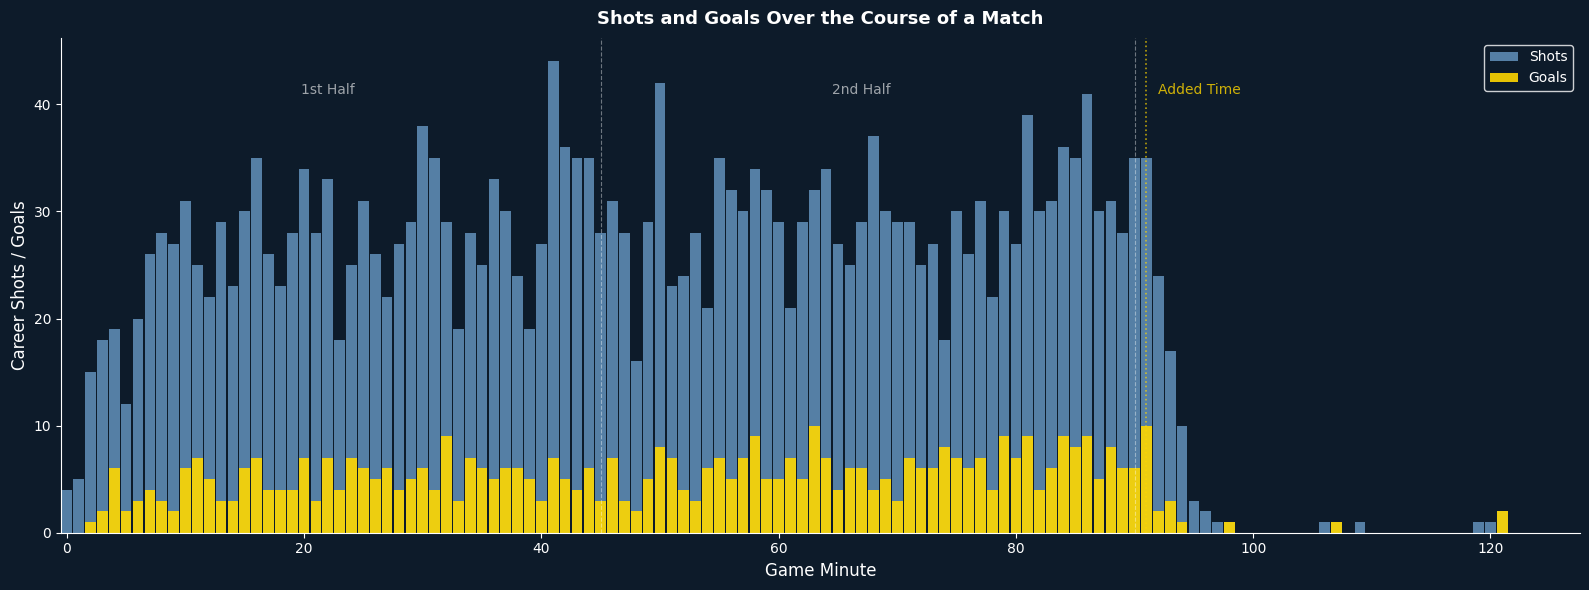

Saved fig5_shots_by_minute.png


In [25]:
# Figure 5 — Shots and Goals by Game Minute with Added Time marker
df_min = df.copy()

shot_counts = df_min.groupby('minute').size().reset_index(name='shots')
goal_counts = df_min[df_min['is_goal']==1].groupby('minute').size().reset_index(name='goals')
merged = shot_counts.merge(goal_counts, on='minute', how='left').fillna(0)

fig, ax = plt.subplots(figsize=(16, 6), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

ax.bar(merged['minute'], merged['shots'], color=LIGHT_BLUE, alpha=0.7, width=0.9, label='Shots')
ax.bar(merged['minute'], merged['goals'], color=GOLD, alpha=0.9, width=0.9, label='Goals')

# Half and added time dividers
added_time_start = df_min[df_min['minute'] > 90]['minute'].min()  # first actual extra time minute

ax.axvline(45,                color=WHITE, linewidth=0.8, linestyle='--', alpha=0.4)
ax.axvline(90,                color=WHITE, linewidth=0.8, linestyle='--', alpha=0.4)
ax.axvline(added_time_start,  color=GOLD,  linewidth=1.2, linestyle=':',  alpha=0.7)

ymax = merged['shots'].max()
ax.text(22,                  ymax*0.93, '1st Half',    color=WHITE, fontsize=10, ha='center', alpha=0.6)
ax.text(67,                  ymax*0.93, '2nd Half',    color=WHITE, fontsize=10, ha='center', alpha=0.6)
ax.text(added_time_start + 1, ymax*0.93, 'Added Time', color=GOLD,  fontsize=10, ha='left',   alpha=0.8)

ax.set_xlabel('Game Minute', fontsize=12)
ax.set_ylabel('Career Shots / Goals', fontsize=12)
ax.set_title('Shots and Goals Over the Course of a Match',
             fontsize=13, color=WHITE, pad=10, fontweight='bold')
ax.set_xlim(left=-0.5)
ax.legend(facecolor=DARK_BG, edgecolor=WHITE, labelcolor=WHITE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_shots_by_minute.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig5_shots_by_minute.png')

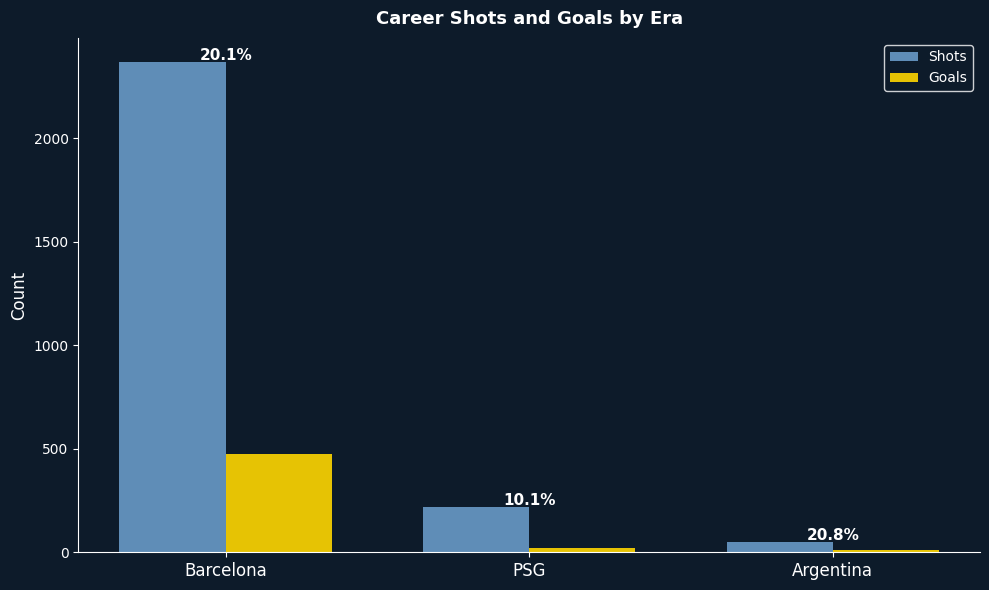

Saved fig6_shots_by_era.png


In [27]:
# Figure 6 — Career Shots and Goals by Era
era_stats = df.groupby('era').agg(
    shots=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).reset_index()
era_stats['accuracy'] = era_stats['goals'] / era_stats['shots']
era_stats = era_stats.sort_values('shots', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

x = np.arange(len(era_stats))
width = 0.35
ax.bar(x - width/2, era_stats['shots'], width, color=LIGHT_BLUE, alpha=0.8, label='Shots')
ax.bar(x + width/2, era_stats['goals'], width, color=GOLD,       alpha=0.9, label='Goals')

for i, row in era_stats.reset_index(drop=True).iterrows():
    ax.text(i, max(row['shots'], row['goals']) + 10,
            f"{row['accuracy']*100:.1f}%", ha='center', fontsize=11,
            color=WHITE, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(era_stats['era'], fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Career Shots and Goals by Era',
             fontsize=13, color=WHITE, pad=10, fontweight='bold')
ax.legend(facecolor=DARK_BG, edgecolor=WHITE, labelcolor=WHITE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_shots_by_era.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig6_shots_by_era.png')

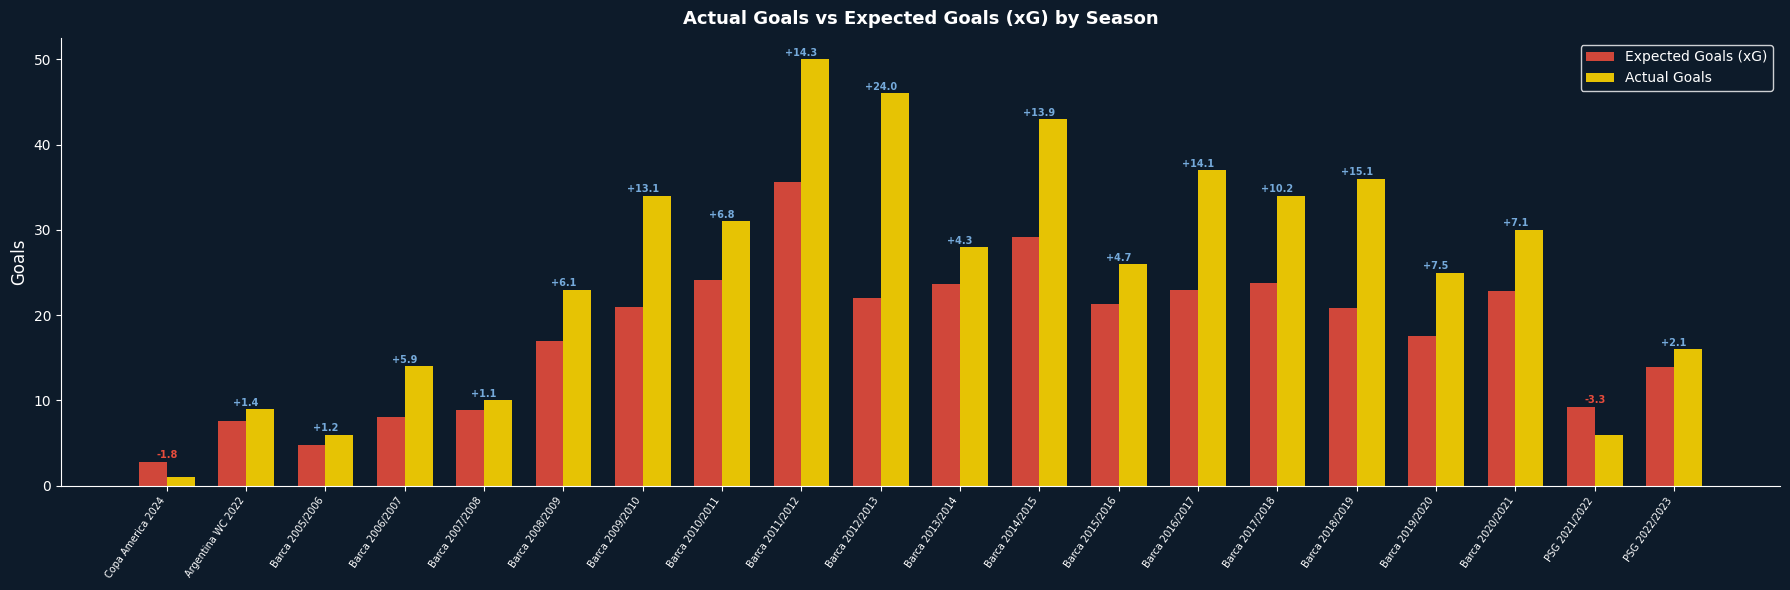

Saved fig7_xg_vs_goals.png


In [34]:
# Figure 7 — xG vs Actual Goals by Season (side by side)
season_stats = df.groupby('competition').agg(
    goals=('is_goal', 'sum'),
    xg=('xg', 'sum'),
    shots=('is_goal', 'count')
).reset_index()
season_stats = season_stats[season_stats['shots'] >= 10]
season_stats['xg_diff'] = season_stats['goals'] - season_stats['xg']
season_stats = season_stats.sort_values('competition')

# Swap competition name for team name, keep the year
def get_team_label(comp):
    if 'Liga' in comp or 'Champions' in comp or 'Copa del Rey' in comp:
        return comp.replace('La Liga', 'Barca').replace('Champions League', 'Barca UCL').replace('Copa del Rey', 'Barca CDR')
    if 'Ligue' in comp:
        return comp.replace('Ligue 1', 'PSG')
    if 'MLS' in comp:
        return comp.replace('Major League Soccer', 'Inter Miami')
    if 'World Cup' in comp:
        return comp.replace('FIFA World Cup', 'Argentina WC')
    if 'Copa América' in comp:
        return comp.replace('Copa América', 'Argentina CA')
    return comp

season_stats['label'] = season_stats['competition'].apply(get_team_label)

fig, ax = plt.subplots(figsize=(18, 6), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

x     = np.arange(len(season_stats))
width = 0.35

ax.bar(x - width/2, season_stats['xg'],    color='#E74C3C', alpha=0.9, width=width, label='Expected Goals (xG)')
ax.bar(x + width/2, season_stats['goals'], color=GOLD,      alpha=0.9, width=width, label='Actual Goals')

for i, row in season_stats.reset_index(drop=True).iterrows():
    diff  = row['goals'] - row['xg']
    color = LIGHT_BLUE if diff >= 0 else '#E74C3C'
    sign  = '+' if diff >= 0 else ''
    ax.text(i, max(row['goals'], row['xg']) + 0.4,
            f"{sign}{diff:.1f}", ha='center', fontsize=7,
            color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(season_stats['label'], rotation=55, ha='right', fontsize=7)
ax.set_ylabel('Goals', fontsize=12)
ax.set_title('Actual Goals vs Expected Goals (xG) by Season',
             fontsize=13, color=WHITE, pad=10, fontweight='bold')
ax.legend(facecolor=DARK_BG, edgecolor=WHITE, labelcolor=WHITE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig7_xg_vs_goals.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig7_xg_vs_goals.png')

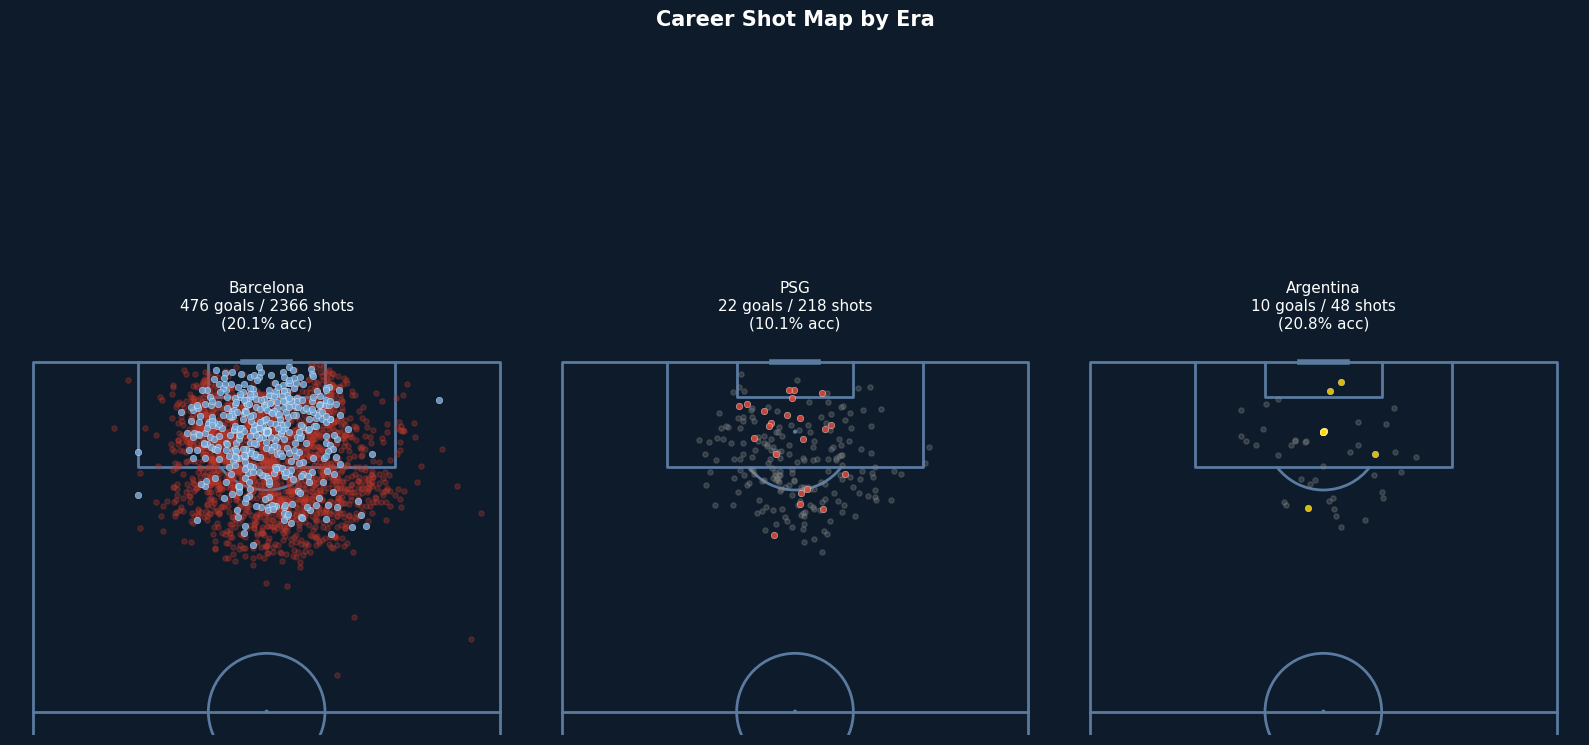

Saved fig8_shot_map_by_era.png


In [38]:
# Figure 8 — Shot Map by Era
from mplsoccer import VerticalPitch

eras = ['Barcelona', 'PSG', 'Argentina']
era_colors = {
    'Barcelona':   {'goal': LIGHT_BLUE, 'miss': MISS_COLOR},
    'PSG':         {'goal': '#E74C3C',  'miss': '#888888'},
    'Argentina':   {'goal': GOLD,       'miss': '#888888'},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 10), facecolor=DARK_BG)
fig.suptitle('Career Shot Map by Era', fontsize=15,
             color=WHITE, fontweight='bold', y=1.01)

for ax, era in zip(axes, eras):
    pitch = VerticalPitch(
        pitch_type='statsbomb',
        pitch_color=DARK_BG, line_color='#5A7A9F',
        half=True
    )
    pitch.draw(ax=ax)
    ax.set_facecolor(DARK_BG)

    subset = df[df['era'] == era]
    goals_e  = subset[subset['is_goal'] == 1]
    misses_e = subset[subset['is_goal'] == 0]

    pitch.scatter(misses_e['x'], misses_e['y'], ax=ax,
                  s=14, color=era_colors[era]['miss'],
                  alpha=0.3, zorder=3)
    pitch.scatter(goals_e['x'], goals_e['y'], ax=ax,
                  s=22, color=era_colors[era]['goal'],
                  alpha=0.85, edgecolors=WHITE,
                  linewidths=0.3, zorder=4)

    ax.set_title(
        f'{era}\n{len(goals_e)} goals / {len(subset)} shots\n'
        f'({len(goals_e)/len(subset)*100:.1f}% acc)' if len(subset) > 0 else era,
        fontsize=11, color=WHITE, pad=8
    )

plt.tight_layout()
plt.savefig('fig8_shot_map_by_era.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved fig8_shot_map_by_era.png')